# 회귀 모델 비교 시각화 (LightGBM vs DeepLearning MLP)

이 노트북은 `new_flight_weather_merged.csv`를 불러와서:
- 상태가 **지연**인 샘플만 대상으로 `지연_분` 회귀
- **LightGBMRegressor** vs **DeepLearning MLP** 비교

을 같은 **시간 기준 80/20 split**으로 학습/예측한 뒤,
**리더보드 + 실제vs예측 + 잔차분포 + 오차허용치 적중률 + 구간별 MAE** 시각화를 생성합니다.

> ✅ 기존 파일들 기준으로 맞춰둠:
> - `5.머신러닝_회귀분석_모델비교 시각화.ipynb` (ML/LGBM)
> - `6. 회귀분석_..._DeepLearning.ipynb` (DL)

---
## 사용법
1) 아래 `csv_path`만 본인 환경에 맞게 수정  
2) 위에서 아래로 순서대로 실행


In [1]:
# =========================
# ✅ 0) 환경 설정
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

np.random.seed(42)

csv_path = r"data/new_flight_weather_merged.csv"  # 예: r"C:/ai/1month/data/new_flight_weather_merged.csv"
MAX_DELAY = 360  # 기존 파일과 동일 (상한 컷)


In [2]:
# =========================
# 1) 데이터 로드 + 회귀 대상 추출/정제
# =========================
df = pd.read_csv(csv_path)
print("✅ CSV 로드:", len(df))

if "상태" not in df.columns:
    raise KeyError("❌ '상태' 컬럼이 없습니다.")
if "지연_분" not in df.columns:
    raise KeyError("❌ '지연_분' 컬럼이 없습니다.")

reg_df = df[df["상태"] == "지연"].copy()
print("⏱ 상태=지연:", len(reg_df))

# target 정제
reg_df = reg_df[reg_df["지연_분"].notna()].copy()
reg_df = reg_df[reg_df["지연_분"] >= 0].copy()
reg_df = reg_df[reg_df["지연_분"] <= MAX_DELAY].copy()

# departure_datetime
if "departure_datetime" not in reg_df.columns:
    raise KeyError("❌ 'departure_datetime' 컬럼이 없습니다.")
reg_df["departure_datetime"] = pd.to_datetime(reg_df["departure_datetime"], errors="coerce")
reg_df = reg_df[reg_df["departure_datetime"].notna()].copy()

# 시간 파생(없으면 생성)
if "dep_hour" not in reg_df.columns:
    reg_df["dep_hour"] = reg_df["departure_datetime"].dt.hour
if "dep_weekday" not in reg_df.columns:
    reg_df["dep_weekday"] = reg_df["departure_datetime"].dt.weekday
if "is_weekend" not in reg_df.columns:
    reg_df["is_weekend"] = reg_df["dep_weekday"].isin([5, 6]).astype(int)

print("📊 target 분포(정제 후)")
display(reg_df["지연_분"].describe().to_frame("지연_분"))


C:\Users\Admin\AppData\Local\Temp\ipykernel_4920\1194913348.py:4: DtypeWarning: Columns (31,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


✅ CSV 로드: 2836872
⏱ 상태=지연: 480982
📊 target 분포(정제 후)


,지연_분
count,479429.000000
mean,56.744999
std,34.943600
min,0.000000
25%,36.000000
50%,46.000000
75%,64.000000
max,360.000000


In [3]:
# =========================
# 2) arrival_code 생성 + Feature 정의
# =========================
# ✅ arrival_code는 num_cols로 쓸 예정: int 고정
if "arrival_code" in reg_df.columns:
    reg_df["arrival_code"] = (
        pd.to_numeric(reg_df["arrival_code"], errors="coerce")
          .fillna(-1).astype(int)
    )
elif "도착지" in reg_df.columns:
    tmp = pd.to_numeric(reg_df["도착지"], errors="coerce")
    if tmp.notna().mean() > 0.7:
        reg_df["arrival_code"] = tmp.fillna(-1).astype(int)
    else:
        reg_df["arrival_code"] = reg_df["도착지"].astype("category").cat.codes.astype(int)
else:
    reg_df["arrival_code"] = -1

num_cols = ["기온(°C)", "풍속_ms", "dep_hour", "dep_weekday", "is_weekend", "arrival_code"]

# ✅ 항공사/공항명 둘 중 존재하는 것을 사용 (노트북 5 vs 6 차이 대응)
airline_like = None
for cand in ["항공사", "공항명"]:
    if cand in reg_df.columns:
        airline_like = cand
        break

cat_cols = []
if airline_like is not None:
    cat_cols.append(airline_like)
for cand in ["출발지", "flight_type"]:
    if cand in reg_df.columns:
        cat_cols.append(cand)

num_cols = [c for c in num_cols if c in reg_df.columns]
cat_cols = [c for c in cat_cols if c in reg_df.columns]
X_cols = num_cols + cat_cols

if not X_cols:
    raise ValueError("❌ X_cols가 비었습니다. 컬럼명을 확인하세요.")

print("✅ num_cols:", num_cols)
print("✅ cat_cols:", cat_cols)
print("✅ X_cols:", X_cols)

✅ num_cols: ['기온(°C)', '풍속_ms', 'dep_hour', 'dep_weekday', 'is_weekend', 'arrival_code']
✅ cat_cols: ['항공사', '출발지', 'flight_type']
✅ X_cols: ['기온(°C)', '풍속_ms', 'dep_hour', 'dep_weekday', 'is_weekend', 'arrival_code', '항공사', '출발지', 'flight_type']


In [4]:
# =========================
# 3) 시간 기준 80/20 split
# =========================
reg_df = reg_df.sort_values("departure_datetime")
split_date = reg_df["departure_datetime"].quantile(0.8)

train_df = reg_df[reg_df["departure_datetime"] <= split_date]
test_df  = reg_df[reg_df["departure_datetime"] > split_date]

X_train = train_df[X_cols].copy()
y_train = train_df["지연_분"].astype(float).copy()
X_test  = test_df[X_cols].copy()
y_test  = test_df["지연_분"].astype(float).copy()

print("✅ Split")
print("Train:", len(train_df), "| Test:", len(test_df))


✅ Split
Train: 383544 | Test: 95885


## 4) 공통 전처리 (OneHot) + LightGBMRegressor 학습/예측

기존 회귀 머신러닝 파일 방식과 동일:
- num: median impute
- cat: UNKNOWN + OneHot
- LGBMRegressor 파이프라인


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from lightgbm import LGBMRegressor

# 전처리
num_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median"))])
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

lgbm_reg = Pipeline([
    ("prep", preprocessor),
    ("reg", LGBMRegressor(
        objective="regression",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

lgbm_reg.fit(X_train, y_train)
y_pred_lgbm = lgbm_reg.predict(X_test)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002986 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 662
[LightGBM] [Info] Number of data points in the train set: 383544, number of used features: 129
[LightGBM] [Info] Start training from score 57.365679


## 5) DeepLearning MLP 회귀 학습/예측

기존 딥러닝 회귀 파일 방식과 동일:
- 위에서 만든 `preprocessor` 그대로 사용
- 원핫이 너무 넓으면 SVD로 축소(옵션)


In [6]:
import tensorflow as tf
from sklearn.decomposition import TruncatedSVD

np.random.seed(42)
tf.random.set_seed(42)

# 전처리 동일 적용
X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp  = preprocessor.transform(X_test)

USE_SVD_IF_WIDE = True
SVD_THRESHOLD = 20000
SVD_COMPONENTS = 512

if USE_SVD_IF_WIDE and X_train_pp.shape[1] > SVD_THRESHOLD:
    print(f"[INFO] 특성 {X_train_pp.shape[1]}개 -> TruncatedSVD({SVD_COMPONENTS})로 축소")
    svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=42)
    X_train_pp = svd.fit_transform(X_train_pp)
    X_test_pp  = svd.transform(X_test_pp)
else:
    if hasattr(X_train_pp, "toarray"):
        X_train_pp = X_train_pp.toarray()
        X_test_pp  = X_test_pp.toarray()

X_train_pp = X_train_pp.astype(np.float32)
X_test_pp  = X_test_pp.astype(np.float32)

y_train_np = y_train.values.astype(np.float32)
y_test_np  = y_test.values.astype(np.float32)

# tf.data
BATCH_SIZE = 256
train_ds = tf.data.Dataset.from_tensor_slices((X_train_pp, y_train_np))\
    .shuffle(min(len(X_train_pp), 20000), seed=42)\
    .batch(BATCH_SIZE)\
    .prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test_pp, y_test_np))\
    .batch(BATCH_SIZE)\
    .prefetch(tf.data.AUTOTUNE)

# 모델
input_dim = X_train_pp.shape[1]
dl_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])

dl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_mae", mode="min", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_mae", mode="min", factor=0.5, patience=4, min_lr=1e-6),
]

history = dl_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=200,
    callbacks=callbacks,
    verbose=1
)

y_pred_dl = dl_model.predict(X_test_pp).ravel()


Epoch 1/200
1499/1499 [==============================] - 6s 3ms/step - loss: 1162.7742 - mae: 21.4616 - val_loss: 924.5333 - val_mae: 21.1886 - lr: 0.0010
Epoch 2/200
1499/1499 [==============================] - 5s 3ms/step - loss: 1073.8800 - mae: 20.6155 - val_loss: 903.7896 - val_mae: 20.4157 - lr: 0.0010
Epoch 3/200
1499/1499 [==============================] - 5s 3ms/step - loss: 1061.6539 - mae: 20.5142 - val_loss: 882.9343 - val_mae: 18.9204 - lr: 0.0010
Epoch 4/200
1499/1499 [==============================] - 5s 3ms/step - loss: 1050.8232 - mae: 20.4336 - val_loss: 913.3828 - val_mae: 17.4466 - lr: 0.0010
Epoch 5/200
1499/1499 [==============================] - 5s 3ms/step - loss: 1037.3418 - mae: 20.3227 - val_loss: 885.4373 - val_mae: 20.1509 - lr: 0.0010
Epoch 6/200
1499/1499 [==============================] - 5s 3ms/step - loss: 1024.1752 - mae: 20.2107 - val_loss: 888.4142 - val_mae: 20.7140 - lr: 0.0010
Epoch 7/200
1499/1499 [==============================] - 5s 3ms/step -

## 6) 비교 리더보드 + 시각화

,model,MAE,RMSE,R2
0,DL_MLP,17.446610,30.222226,0.057338
1,LGBM,20.550759,29.122512,0.124692


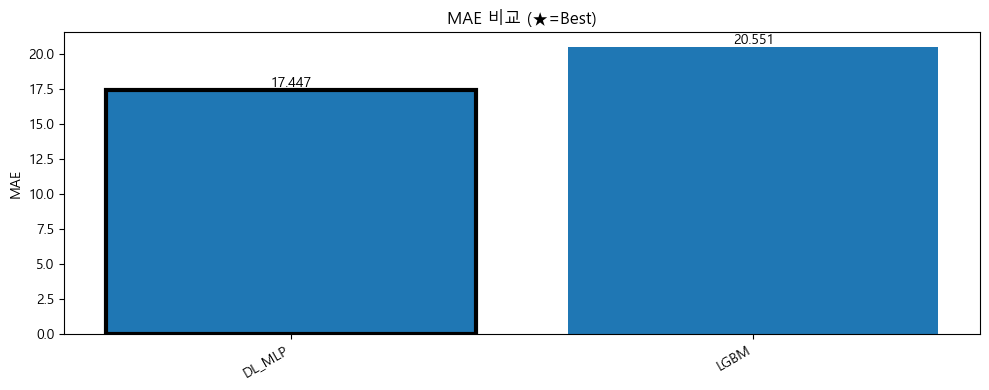

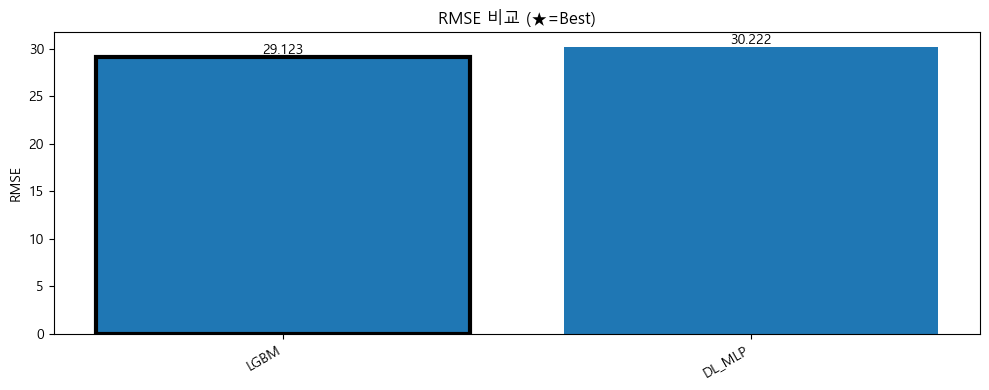

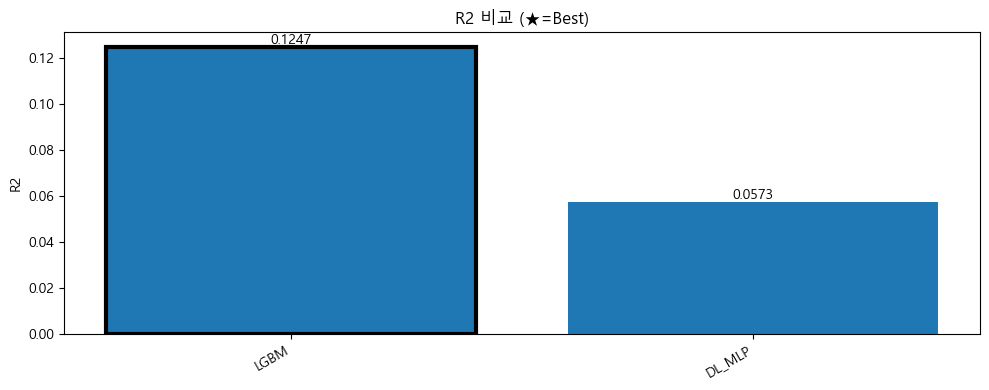

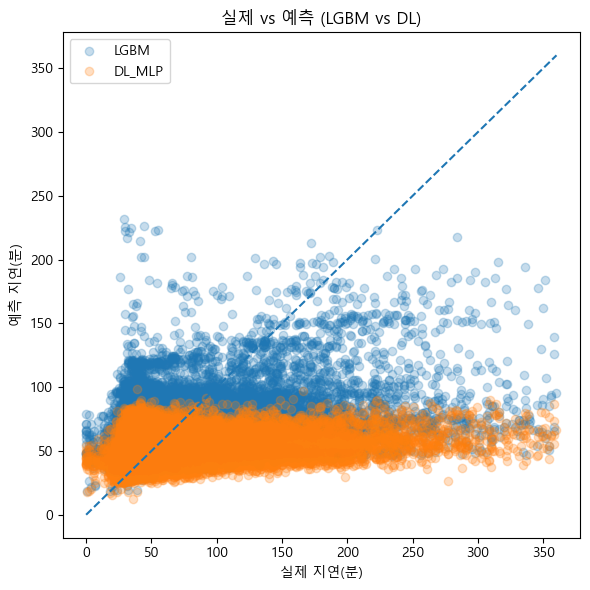

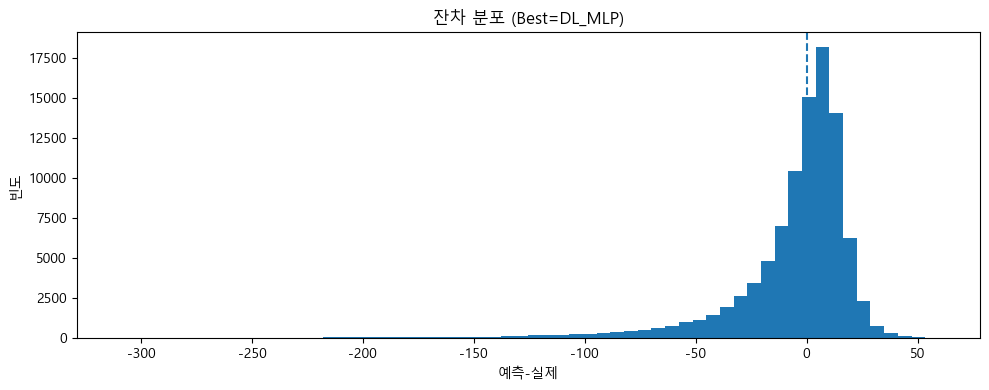

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

preds = {
    "LGBM": np.asarray(y_pred_lgbm).reshape(-1),
    "DL_MLP": np.asarray(y_pred_dl).reshape(-1),
}
y_true = np.asarray(y_test).reshape(-1)

rows = []
for name, yhat in preds.items():
    rows.append([name,
                 mean_absolute_error(y_true, yhat),
                 rmse(y_true, yhat),
                 r2_score(y_true, yhat)])

leaderboard = pd.DataFrame(rows, columns=["model","MAE","RMSE","R2"])\
    .sort_values(["MAE","RMSE"], ascending=True).reset_index(drop=True)
display(leaderboard)

# ---- Bar charts
def bar_rank(metric, lower_is_better=True, fmt=None):
    d = leaderboard.sort_values(metric, ascending=lower_is_better)
    best = d.iloc[0]["model"]

    plt.figure(figsize=(10,4))
    bars = plt.bar(d["model"], d[metric])

    # ✅ 표시 포맷 자동(기본: 소수 4자리)
    if fmt is None:
        fmt = ".4f"

    # ✅ 막대 위에 값 라벨 찍기
    for b, m, val in zip(bars, d["model"], d[metric].values):
        # best 강조
        if m == best:
            b.set_edgecolor("black")
            b.set_linewidth(3)

        plt.text(
            b.get_x() + b.get_width()/2,
            b.get_height(),
            format(val, fmt),
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric} 비교 (★=Best)")
    plt.tight_layout()
    plt.show()

bar_rank("MAE", True, fmt=".3f")
bar_rank("RMSE", True, fmt=".3f")
bar_rank("R2", False, fmt=".4f")


# ---- Actual vs Pred (scatter)
plt.figure(figsize=(6,6))
mn = min(y_true.min(), min(v.min() for v in preds.values()))
mx = max(y_true.max(), max(v.max() for v in preds.values()))
plt.plot([mn,mx],[mn,mx], linestyle="--")
for name, yhat in preds.items():
    plt.scatter(y_true, yhat, alpha=0.25, label=name)
plt.xlabel("실제 지연(분)")
plt.ylabel("예측 지연(분)")
plt.title("실제 vs 예측 (LGBM vs DL)")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Residual histogram (best)
best = leaderboard.iloc[0]["model"]
res = preds[best] - y_true
plt.figure(figsize=(10,4))
plt.hist(res, bins=60)
plt.axvline(0, linestyle="--")
plt.title(f"잔차 분포 (Best={best})")
plt.xlabel("예측-실제")
plt.ylabel("빈도")
plt.tight_layout()
plt.show()


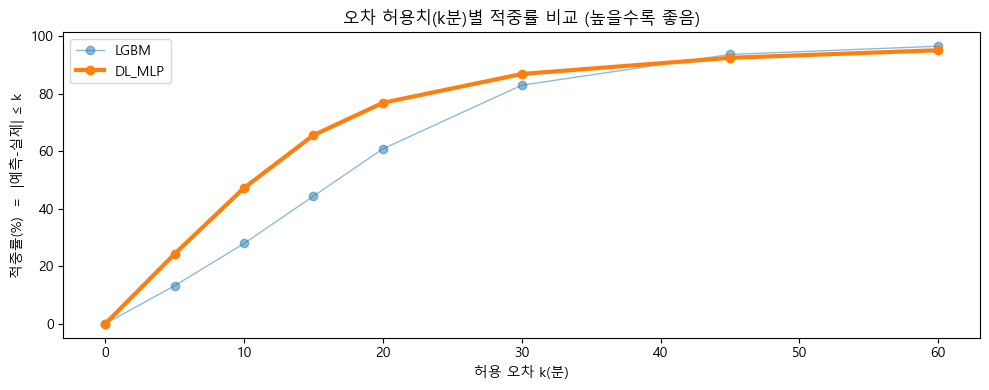

In [8]:
# =========================
# 7) 오차 허용치(k분)별 적중률 비교
# =========================
thresholds = [0, 5, 10, 15, 20, 30, 45, 60]

plt.figure(figsize=(10,4))
for name, yhat in preds.items():
    abs_err = np.abs(yhat - y_true)
    acc = [(abs_err <= t).mean() * 100 for t in thresholds]
    plt.plot(thresholds, acc, marker="o", label=name, linewidth=3 if name==leaderboard.iloc[0]["model"] else 1, alpha=1 if name==leaderboard.iloc[0]["model"] else 0.5)

plt.title("오차 허용치(k분)별 적중률 비교 (높을수록 좋음)")
plt.xlabel("허용 오차 k(분)")
plt.ylabel("적중률(%)  =  |예측-실제| ≤ k")
plt.legend()
plt.tight_layout()
plt.show()


,model,segment,MAE
6,DL_MLP,0~10,37.247696
0,LGBM,0~10,47.920630
7,DL_MLP,10~30,15.012645
1,LGBM,10~30,23.448130
4,LGBM,120~240,77.651020
10,DL_MLP,120~240,100.839733
5,LGBM,240~360,187.602529
11,DL_MLP,240~360,222.589383
8,DL_MLP,30~60,8.706724
2,LGBM,30~60,16.771787


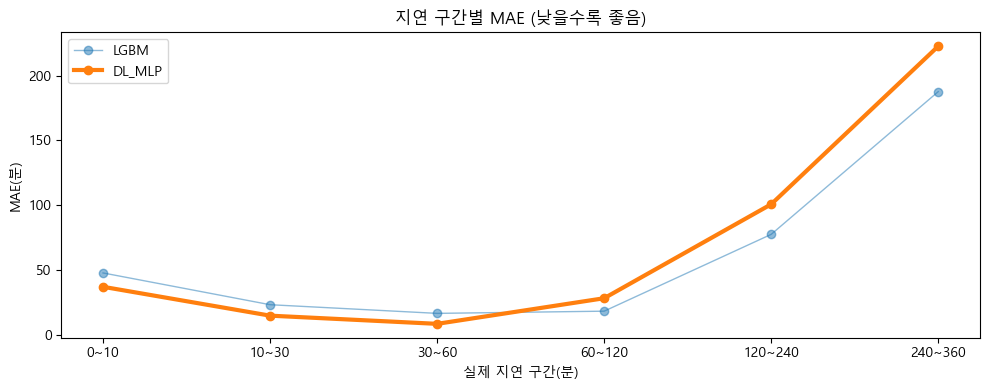

In [9]:
# =========================
# 8) 지연 구간별 MAE (긴 지연에서도 누가 덜 무너지는지)
# =========================
bins = [0, 10, 30, 60, 120, 240, 360]
labels = [f"{bins[i]}~{bins[i+1]}" for i in range(len(bins)-1)]

bucket = pd.cut(y_true, bins=bins, labels=labels, include_lowest=True)
bucket_rows = []
for name, yhat in preds.items():
    for seg in labels:
        mask = (bucket == seg)
        if mask.sum() < 30:
            continue
        bucket_rows.append([name, seg, mean_absolute_error(y_true[mask], yhat[mask])])

bucket_df = pd.DataFrame(bucket_rows, columns=["model","segment","MAE"])
display(bucket_df.sort_values(["segment","MAE"]).head(50))

# plot
if len(bucket_df) > 0:
    plt.figure(figsize=(10,4))
    for name in preds.keys():
        sub = bucket_df[bucket_df["model"]==name]
        # segment order 유지
        seg_order = [s for s in labels if s in sub["segment"].unique()]
        yvals = [sub[sub["segment"]==s]["MAE"].mean() for s in seg_order]
        plt.plot(seg_order, yvals, marker="o", label=name, alpha=1 if name==leaderboard.iloc[0]["model"] else 0.5,
                 linewidth=3 if name==leaderboard.iloc[0]["model"] else 1)
    plt.title("지연 구간별 MAE (낮을수록 좋음)")
    plt.xlabel("실제 지연 구간(분)")
    plt.ylabel("MAE(분)")
    plt.legend()
    plt.tight_layout()
    plt.show()
